# Food Plate Interactions

In [40]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from IPython.display import display

# ---- Adobe-friendly fonts (must be set BEFORE plotting) ----
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

sns.set(style='whitegrid', context='notebook')

base_dir = '/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/food-plates'

condition_paths = {
    'GH Fed-Fed': 'group-housed/fed-fed',
    'GH Fed-Starved': 'group-housed/fed-starved',
    'GH Starved-Starved': 'group-housed/starved-starved',
    'SI Fed-Fed': 'socially-isolated/fed-fed',
    'SI Fed-Starved': 'socially-isolated/fed-starved',
    'SI Starved-Starved': 'socially-isolated/starved-starved',
}

condition_order = list(condition_paths.keys())
gh_order = ['GH Fed-Fed', 'GH Fed-Starved', 'GH Starved-Starved']
si_order = ['SI Fed-Fed', 'SI Fed-Starved', 'SI Starved-Starved']
feeding_order = ['Fed-Fed', 'Fed-Starved', 'Starved-Starved']

palette = {
    'Fed-Fed': '#4C72B0',
    'Fed-Starved': '#55A868',
    'Starved-Starved': '#C44E52',
}

bouts_dfs = []
frames_dfs = []

for condition, rel_path in condition_paths.items():
    bouts_temp = pd.read_csv(f'{base_dir}/{rel_path}/food_plate_interaction_bouts.csv')
    frames_temp = pd.read_csv(f'{base_dir}/{rel_path}/food_plate_interaction_frames.csv')

    for temp in [bouts_temp, frames_temp]:
        temp['Condition'] = condition
        temp['Housing'] = 'GH' if condition.startswith('GH') else 'SI'
        temp['Feeding'] = condition.replace('GH ', '').replace('SI ', '')

    bouts_dfs.append(bouts_temp)
    frames_dfs.append(frames_temp)

bouts_raw = pd.concat(bouts_dfs, ignore_index=True)
frames_raw = pd.concat(frames_dfs, ignore_index=True)

all_files = frames_raw[['Condition', 'Housing', 'Feeding', 'file']].drop_duplicates().copy()

# Remove placeholder rows from files with no interactions.
bouts = bouts_raw.dropna(subset=['start_frame']).copy()
frames = frames_raw.dropna(subset=['frame']).copy()

# Before any digging = neither larva has dug yet.
bouts_before_digging = bouts[bouts['start_dug_context'] == 'neither_dug'].copy()
frames_before_digging = frames[frames['dug_context'] == 'neither_dug'].copy()

interaction_type_order = sorted(bouts['initial_type'].dropna().unique())

print('bouts:', bouts.shape)
print('frames:', frames.shape)
display(bouts.head())
display(frames.head())

bouts: (550, 40)
frames: (2439, 20)


,file,bout_id,track_1,track_2,start_frame,end_frame,duration,initial_type,predominant_type,start_track_1_digging_status,...,both_digging_same_frame_during_bout,head_head,tail_tail,body_body,body_head,body_tail,head_tail,Condition,Housing,Feeding
0,2026-03-09_12-32-18_td9.tracks.feather,0,0,1,1109,1109,1,head_tail,head_tail,False,...,False,0,0,0,0,0,1,GH Fed-Fed,GH,Fed-Fed
1,2026-03-09_12-35-46_td11.tracks.feather,0,0,1,375,376,2,head_head,head_head,False,...,False,2,0,0,0,0,0,GH Fed-Fed,GH,Fed-Fed
2,2026-03-09_12-35-46_td11.tracks.feather,1,0,1,386,393,8,head_tail,head_tail,False,...,False,2,1,1,1,3,5,GH Fed-Fed,GH,Fed-Fed
3,2026-03-09_12-35-46_td11.tracks.feather,2,0,1,667,670,4,head_head,head_head,False,...,False,4,0,0,0,0,0,GH Fed-Fed,GH,Fed-Fed
4,2026-03-09_12-35-46_td11.tracks.feather,3,0,1,1027,1034,8,head_head,head_head,False,...,False,4,0,0,2,0,2,GH Fed-Fed,GH,Fed-Fed


,file,frame,Interaction Pair,track_1,track_2,track_1_node,track_2_node,Distance,Closest Interaction Type,track_1_digging_status,track_2_digging_status,track_1_has_dug,track_2_has_dug,active_digging_count,active_digging_context,dug_count,dug_context,Condition,Housing,Feeding
0,2026-04-21_12-50-08_td8.tracks.feather,83.0,"(0, 1)",0.0,1.0,head,head,0.644764,head_head,False,False,False,False,0.0,neither_dug,0.0,neither_dug,GH Fed-Fed,GH,Fed-Fed
1,2026-04-21_12-50-08_td8.tracks.feather,162.0,"(0, 1)",0.0,1.0,head,body,0.934919,body_head,False,False,False,False,0.0,neither_dug,0.0,neither_dug,GH Fed-Fed,GH,Fed-Fed
2,2026-04-21_12-50-08_td8.tracks.feather,163.0,"(0, 1)",0.0,1.0,head,body,0.706650,body_head,False,False,False,False,0.0,neither_dug,0.0,neither_dug,GH Fed-Fed,GH,Fed-Fed
3,2026-04-21_12-50-08_td8.tracks.feather,164.0,"(0, 1)",0.0,1.0,head,head,0.744304,head_head,False,False,False,False,0.0,neither_dug,0.0,neither_dug,GH Fed-Fed,GH,Fed-Fed
4,2026-04-21_12-50-08_td8.tracks.feather,362.0,"(0, 1)",0.0,1.0,head,tail,0.727945,head_tail,False,False,False,False,0.0,neither_dug,0.0,neither_dug,GH Fed-Fed,GH,Fed-Fed


## 1. Total Contact Frames Per Condition

/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_43198/2705076426.py:18: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=gh, x='Feeding', y='contact_frames', order=feeding_order, palette=palette, ci='sd', ax=axes[0])
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_43198/2705076426.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=gh, x='Feeding', y='contact_frames', order=feeding_order, palette=palette, ci='sd', ax=axes[0])
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_43198/2705076426.py:26: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=si, x='Feeding', y='contact_frames', order=feeding_order, palette=palette, ci='sd', ax=axes[1])
/var/folders/w9/3f6w3lj91rl9n89tt8fnj

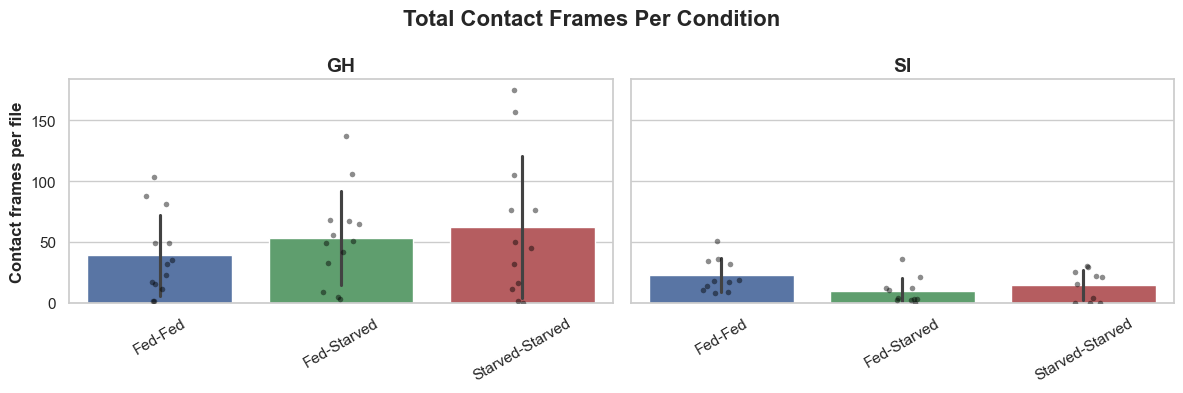

In [41]:
contact_frames_per_file = (
    frames.groupby(['Condition', 'Housing', 'Feeding', 'file'])
          .size()
          .reset_index(name='contact_frames')
)

contact_frames_per_file = (
    all_files
    .merge(contact_frames_per_file, on=['Condition', 'Housing', 'Feeding', 'file'], how='left')
    .fillna({'contact_frames': 0})
)

gh = contact_frames_per_file[contact_frames_per_file['Housing'] == 'GH'].copy()
si = contact_frames_per_file[contact_frames_per_file['Housing'] == 'SI'].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

sns.barplot(data=gh, x='Feeding', y='contact_frames', order=feeding_order, palette=palette, ci='sd', ax=axes[0])
sns.stripplot(data=gh, x='Feeding', y='contact_frames', order=feeding_order, color='black', alpha=0.45, size=4, ax=axes[0])
axes[0].set_title('GH', fontsize=14, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Contact frames per file', fontsize=12, fontweight='bold')
axes[0].set_ylim(bottom=0)
axes[0].tick_params(axis='x', rotation=30)

sns.barplot(data=si, x='Feeding', y='contact_frames', order=feeding_order, palette=palette, ci='sd', ax=axes[1])
sns.stripplot(data=si, x='Feeding', y='contact_frames', order=feeding_order, color='black', alpha=0.45, size=4, ax=axes[1])
axes[1].set_title('SI', fontsize=14, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('')
axes[1].set_ylim(bottom=0)
axes[1].tick_params(axis='x', rotation=30)

fig.suptitle('Total Contact Frames Per Condition', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Total Contact Frames Before Any Digging

/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_43198/1249885498.py:18: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=gh, x='Feeding', y='contact_frames', order=feeding_order, palette=palette, ci='sd', ax=axes[0])
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_43198/1249885498.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=gh, x='Feeding', y='contact_frames', order=feeding_order, palette=palette, ci='sd', ax=axes[0])
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_43198/1249885498.py:26: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=si, x='Feeding', y='contact_frames', order=feeding_order, palette=palette, ci='sd', ax=axes[1])
/var/folders/w9/3f6w3lj91rl9n89tt8fnj

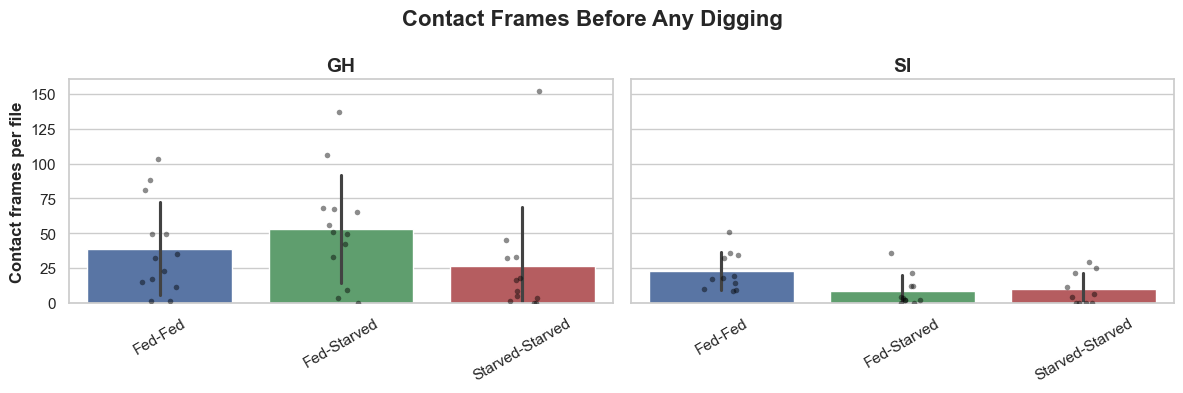

In [42]:
contact_frames_before_per_file = (
    frames_before_digging.groupby(['Condition', 'Housing', 'Feeding', 'file'])
                         .size()
                         .reset_index(name='contact_frames')
)

contact_frames_before_per_file = (
    all_files
    .merge(contact_frames_before_per_file, on=['Condition', 'Housing', 'Feeding', 'file'], how='left')
    .fillna({'contact_frames': 0})
)

gh = contact_frames_before_per_file[contact_frames_before_per_file['Housing'] == 'GH'].copy()
si = contact_frames_before_per_file[contact_frames_before_per_file['Housing'] == 'SI'].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

sns.barplot(data=gh, x='Feeding', y='contact_frames', order=feeding_order, palette=palette, ci='sd', ax=axes[0])
sns.stripplot(data=gh, x='Feeding', y='contact_frames', order=feeding_order, color='black', alpha=0.45, size=4, ax=axes[0])
axes[0].set_title('GH', fontsize=14, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Contact frames per file', fontsize=12, fontweight='bold')
axes[0].set_ylim(bottom=0)
axes[0].tick_params(axis='x', rotation=30)

sns.barplot(data=si, x='Feeding', y='contact_frames', order=feeding_order, palette=palette, ci='sd', ax=axes[1])
sns.stripplot(data=si, x='Feeding', y='contact_frames', order=feeding_order, color='black', alpha=0.45, size=4, ax=axes[1])
axes[1].set_title('SI', fontsize=14, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('')
axes[1].set_ylim(bottom=0)
axes[1].tick_params(axis='x', rotation=30)

fig.suptitle('Contact Frames Before Any Digging', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Number Of Bouts: Total Versus Before Digging

/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_43198/1326338105.py:18: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=gh, x='Feeding', y='number_of_bouts', order=feeding_order, palette=palette, ci='sd', ax=axes[0])
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_43198/1326338105.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=gh, x='Feeding', y='number_of_bouts', order=feeding_order, palette=palette, ci='sd', ax=axes[0])
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_43198/1326338105.py:26: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=si, x='Feeding', y='number_of_bouts', order=feeding_order, palette=palette, ci='sd', ax=axes[1])
/var/folders/w9/3f6w3lj91rl9n89tt8

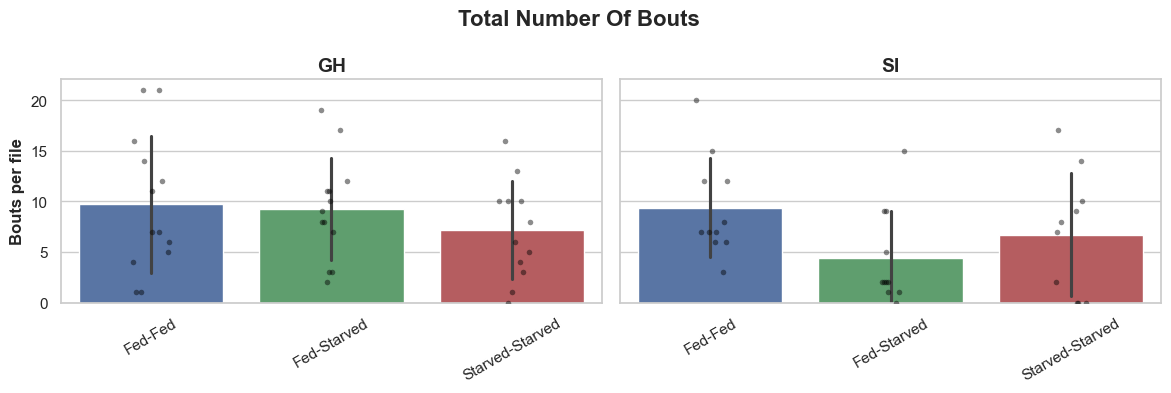

In [43]:
bouts_total_per_file = (
    bouts.groupby(['Condition', 'Housing', 'Feeding', 'file'])
         .size()
         .reset_index(name='number_of_bouts')
)

bouts_total_per_file = (
    all_files
    .merge(bouts_total_per_file, on=['Condition', 'Housing', 'Feeding', 'file'], how='left')
    .fillna({'number_of_bouts': 0})
)

gh = bouts_total_per_file[bouts_total_per_file['Housing'] == 'GH'].copy()
si = bouts_total_per_file[bouts_total_per_file['Housing'] == 'SI'].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

sns.barplot(data=gh, x='Feeding', y='number_of_bouts', order=feeding_order, palette=palette, ci='sd', ax=axes[0])
sns.stripplot(data=gh, x='Feeding', y='number_of_bouts', order=feeding_order, color='black', alpha=0.45, size=4, ax=axes[0])
axes[0].set_title('GH', fontsize=14, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Bouts per file', fontsize=12, fontweight='bold')
axes[0].set_ylim(bottom=0)
axes[0].tick_params(axis='x', rotation=30)

sns.barplot(data=si, x='Feeding', y='number_of_bouts', order=feeding_order, palette=palette, ci='sd', ax=axes[1])
sns.stripplot(data=si, x='Feeding', y='number_of_bouts', order=feeding_order, color='black', alpha=0.45, size=4, ax=axes[1])
axes[1].set_title('SI', fontsize=14, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('')
axes[1].set_ylim(bottom=0)
axes[1].tick_params(axis='x', rotation=30)

fig.suptitle('Total Number Of Bouts', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_43198/2677789488.py:18: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=gh, x='Feeding', y='number_of_bouts', order=feeding_order, palette=palette, ci='sd', ax=axes[0])
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_43198/2677789488.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=gh, x='Feeding', y='number_of_bouts', order=feeding_order, palette=palette, ci='sd', ax=axes[0])
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_43198/2677789488.py:26: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=si, x='Feeding', y='number_of_bouts', order=feeding_order, palette=palette, ci='sd', ax=axes[1])
/var/folders/w9/3f6w3lj91rl9n89tt8

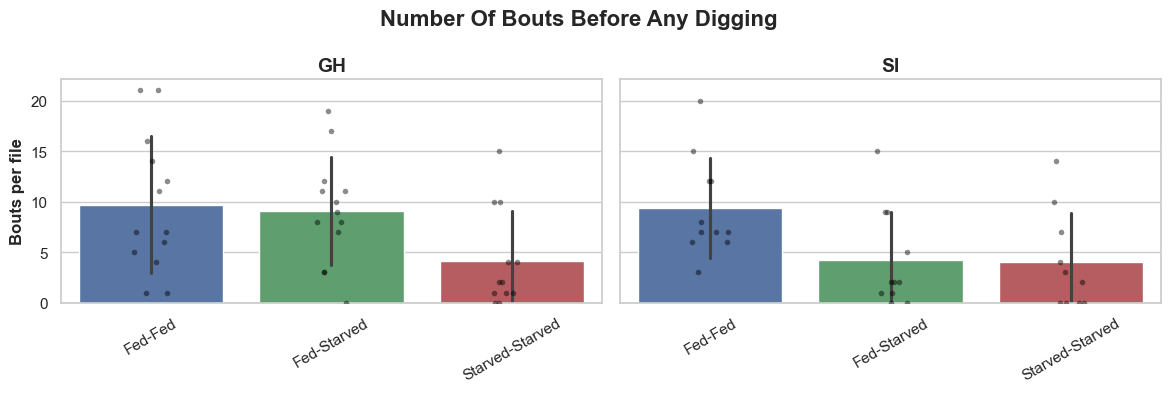

In [44]:
bouts_before_per_file = (
    bouts_before_digging.groupby(['Condition', 'Housing', 'Feeding', 'file'])
                         .size()
                         .reset_index(name='number_of_bouts')
)

bouts_before_per_file = (
    all_files
    .merge(bouts_before_per_file, on=['Condition', 'Housing', 'Feeding', 'file'], how='left')
    .fillna({'number_of_bouts': 0})
)

gh = bouts_before_per_file[bouts_before_per_file['Housing'] == 'GH'].copy()
si = bouts_before_per_file[bouts_before_per_file['Housing'] == 'SI'].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

sns.barplot(data=gh, x='Feeding', y='number_of_bouts', order=feeding_order, palette=palette, ci='sd', ax=axes[0])
sns.stripplot(data=gh, x='Feeding', y='number_of_bouts', order=feeding_order, color='black', alpha=0.45, size=4, ax=axes[0])
axes[0].set_title('GH', fontsize=14, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Bouts per file', fontsize=12, fontweight='bold')
axes[0].set_ylim(bottom=0)
axes[0].tick_params(axis='x', rotation=30)

sns.barplot(data=si, x='Feeding', y='number_of_bouts', order=feeding_order, palette=palette, ci='sd', ax=axes[1])
sns.stripplot(data=si, x='Feeding', y='number_of_bouts', order=feeding_order, color='black', alpha=0.45, size=4, ax=axes[1])
axes[1].set_title('SI', fontsize=14, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('')
axes[1].set_ylim(bottom=0)
axes[1].tick_params(axis='x', rotation=30)

fig.suptitle('Number Of Bouts Before Any Digging', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Duration Of Bouts: Total And Before Digging

/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_43198/1780904290.py:12: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=gh, x='Feeding', y='mean_duration', order=feeding_order, palette=palette, ci='sd', ax=axes[0])
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_43198/1780904290.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=gh, x='Feeding', y='mean_duration', order=feeding_order, palette=palette, ci='sd', ax=axes[0])
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_43198/1780904290.py:20: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=si, x='Feeding', y='mean_duration', order=feeding_order, palette=palette, ci='sd', ax=axes[1])
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h

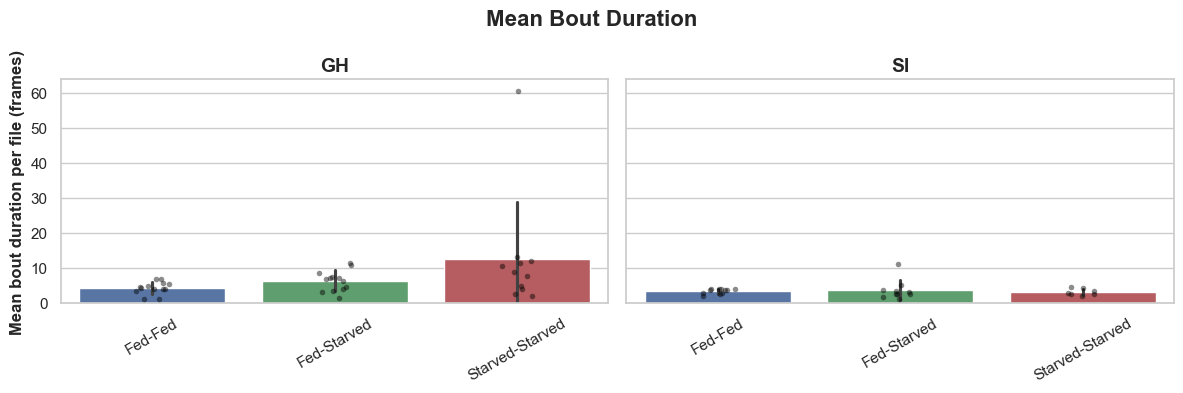

In [45]:
duration_total_per_file = (
    bouts.groupby(['Condition', 'Housing', 'Feeding', 'file'])['duration']
         .mean()
         .reset_index(name='mean_duration')
)

gh = duration_total_per_file[duration_total_per_file['Housing'] == 'GH'].copy()
si = duration_total_per_file[duration_total_per_file['Housing'] == 'SI'].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

sns.barplot(data=gh, x='Feeding', y='mean_duration', order=feeding_order, palette=palette, ci='sd', ax=axes[0])
sns.stripplot(data=gh, x='Feeding', y='mean_duration', order=feeding_order, color='black', alpha=0.45, size=4, ax=axes[0])
axes[0].set_title('GH', fontsize=14, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Mean bout duration per file (frames)', fontsize=12, fontweight='bold')
axes[0].set_ylim(bottom=0)
axes[0].tick_params(axis='x', rotation=30)

sns.barplot(data=si, x='Feeding', y='mean_duration', order=feeding_order, palette=palette, ci='sd', ax=axes[1])
sns.stripplot(data=si, x='Feeding', y='mean_duration', order=feeding_order, color='black', alpha=0.45, size=4, ax=axes[1])
axes[1].set_title('SI', fontsize=14, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('')
axes[1].set_ylim(bottom=0)
axes[1].tick_params(axis='x', rotation=30)

fig.suptitle('Mean Bout Duration', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_43198/2088087084.py:12: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=gh, x='Feeding', y='mean_duration', order=feeding_order, palette=palette, ci='sd', ax=axes[0])
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_43198/2088087084.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=gh, x='Feeding', y='mean_duration', order=feeding_order, palette=palette, ci='sd', ax=axes[0])
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_43198/2088087084.py:20: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=si, x='Feeding', y='mean_duration', order=feeding_order, palette=palette, ci='sd', ax=axes[1])
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h

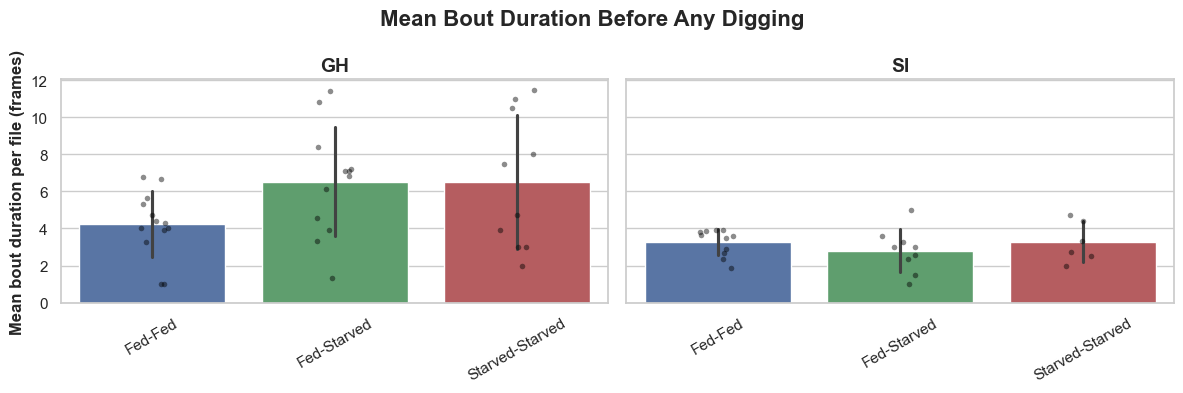

In [46]:
duration_before_per_file = (
    bouts_before_digging.groupby(['Condition', 'Housing', 'Feeding', 'file'])['duration']
                         .mean()
                         .reset_index(name='mean_duration')
)

gh = duration_before_per_file[duration_before_per_file['Housing'] == 'GH'].copy()
si = duration_before_per_file[duration_before_per_file['Housing'] == 'SI'].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

sns.barplot(data=gh, x='Feeding', y='mean_duration', order=feeding_order, palette=palette, ci='sd', ax=axes[0])
sns.stripplot(data=gh, x='Feeding', y='mean_duration', order=feeding_order, color='black', alpha=0.45, size=4, ax=axes[0])
axes[0].set_title('GH', fontsize=14, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Mean bout duration per file (frames)', fontsize=12, fontweight='bold')
axes[0].set_ylim(bottom=0)
axes[0].tick_params(axis='x', rotation=30)

sns.barplot(data=si, x='Feeding', y='mean_duration', order=feeding_order, palette=palette, ci='sd', ax=axes[1])
sns.stripplot(data=si, x='Feeding', y='mean_duration', order=feeding_order, color='black', alpha=0.45, size=4, ax=axes[1])
axes[1].set_title('SI', fontsize=14, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('')
axes[1].set_ylim(bottom=0)
axes[1].tick_params(axis='x', rotation=30)

fig.suptitle('Mean Bout Duration Before Any Digging', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Initial Interaction Type Counts

/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_43198/3051514299.py:28: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=gh, x='initial_type', y='number_of_interactions', hue='Feeding', hue_order=feeding_order, palette=palette, ci='sd', ax=axes[0])
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_43198/3051514299.py:36: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=si, x='initial_type', y='number_of_interactions', hue='Feeding', hue_order=feeding_order, palette=palette, ci='sd', ax=axes[1])


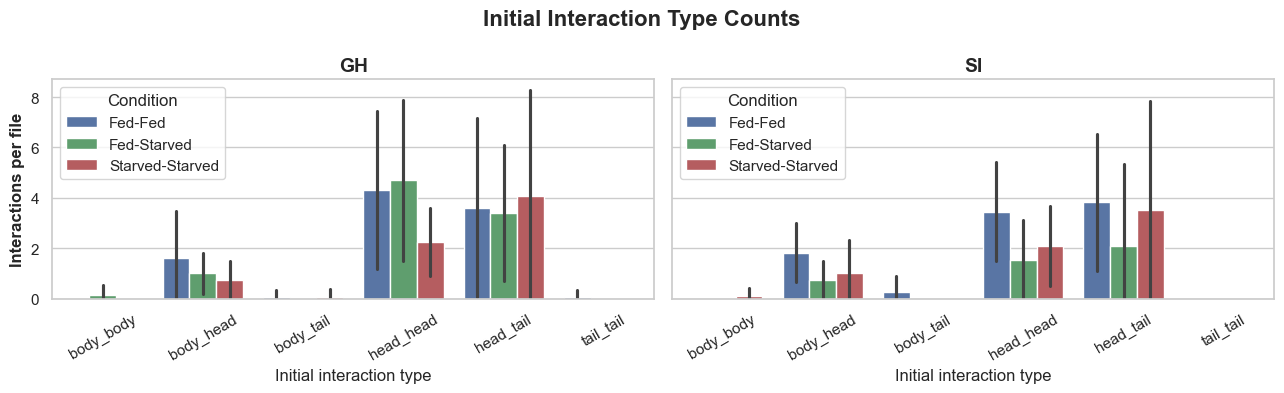

In [47]:
initial_type_counts = (
    bouts.groupby(['Condition', 'Housing', 'Feeding', 'file', 'initial_type'])
         .size()
         .reset_index(name='number_of_interactions')
)

index = pd.MultiIndex.from_product(
    [all_files['file'].unique(), interaction_type_order],
    names=['file', 'initial_type']
)

filled = []
for condition in condition_order:
    files = all_files[all_files['Condition'] == condition][['Condition', 'Housing', 'Feeding', 'file']]
    temp_index = pd.MultiIndex.from_product([files['file'].unique(), interaction_type_order], names=['file', 'initial_type'])
    temp = temp_index.to_frame(index=False).merge(files, on='file', how='left')
    temp = temp.merge(initial_type_counts, on=['Condition', 'Housing', 'Feeding', 'file', 'initial_type'], how='left')
    temp['number_of_interactions'] = temp['number_of_interactions'].fillna(0)
    filled.append(temp)

initial_type_counts = pd.concat(filled, ignore_index=True)

gh = initial_type_counts[initial_type_counts['Housing'] == 'GH'].copy()
si = initial_type_counts[initial_type_counts['Housing'] == 'SI'].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

sns.barplot(data=gh, x='initial_type', y='number_of_interactions', hue='Feeding', hue_order=feeding_order, palette=palette, ci='sd', ax=axes[0])
axes[0].set_title('GH', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Initial interaction type')
axes[0].set_ylabel('Interactions per file', fontsize=12, fontweight='bold')
axes[0].set_ylim(bottom=0)
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(title='Condition')

sns.barplot(data=si, x='initial_type', y='number_of_interactions', hue='Feeding', hue_order=feeding_order, palette=palette, ci='sd', ax=axes[1])
axes[1].set_title('SI', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Initial interaction type')
axes[1].set_ylabel('')
axes[1].set_ylim(bottom=0)
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Condition')

fig.suptitle('Initial Interaction Type Counts', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Initial Interaction Type Counts Before Any Digging

/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_43198/2399362796.py:23: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=gh, x='initial_type', y='number_of_interactions', hue='Feeding', hue_order=feeding_order, palette=palette, ci='sd', ax=axes[0])
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_43198/2399362796.py:31: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=si, x='initial_type', y='number_of_interactions', hue='Feeding', hue_order=feeding_order, palette=palette, ci='sd', ax=axes[1])


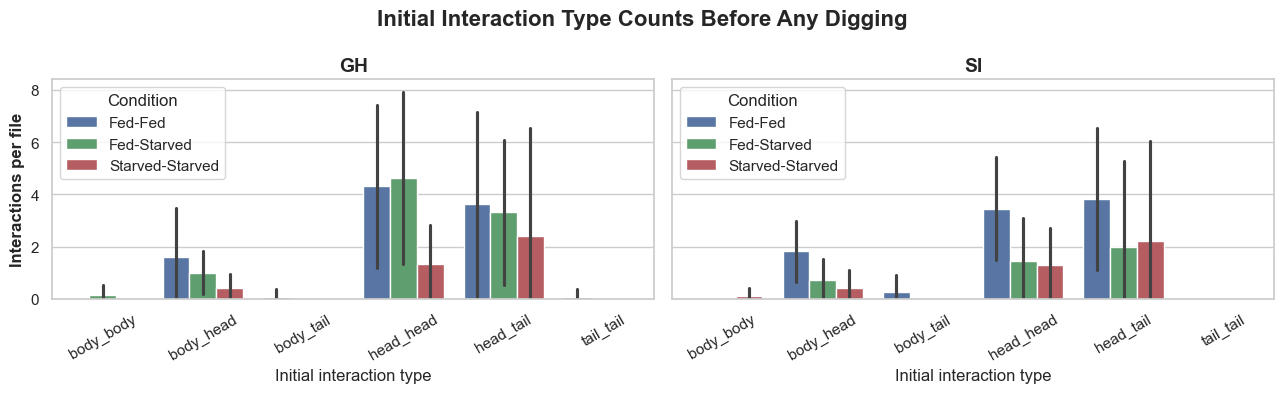

In [48]:
initial_type_counts_before = (
    bouts_before_digging.groupby(['Condition', 'Housing', 'Feeding', 'file', 'initial_type'])
                         .size()
                         .reset_index(name='number_of_interactions')
)

filled = []
for condition in condition_order:
    files = all_files[all_files['Condition'] == condition][['Condition', 'Housing', 'Feeding', 'file']]
    temp_index = pd.MultiIndex.from_product([files['file'].unique(), interaction_type_order], names=['file', 'initial_type'])
    temp = temp_index.to_frame(index=False).merge(files, on='file', how='left')
    temp = temp.merge(initial_type_counts_before, on=['Condition', 'Housing', 'Feeding', 'file', 'initial_type'], how='left')
    temp['number_of_interactions'] = temp['number_of_interactions'].fillna(0)
    filled.append(temp)

initial_type_counts_before = pd.concat(filled, ignore_index=True)

gh = initial_type_counts_before[initial_type_counts_before['Housing'] == 'GH'].copy()
si = initial_type_counts_before[initial_type_counts_before['Housing'] == 'SI'].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

sns.barplot(data=gh, x='initial_type', y='number_of_interactions', hue='Feeding', hue_order=feeding_order, palette=palette, ci='sd', ax=axes[0])
axes[0].set_title('GH', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Initial interaction type')
axes[0].set_ylabel('Interactions per file', fontsize=12, fontweight='bold')
axes[0].set_ylim(bottom=0)
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(title='Condition')

sns.barplot(data=si, x='initial_type', y='number_of_interactions', hue='Feeding', hue_order=feeding_order, palette=palette, ci='sd', ax=axes[1])
axes[1].set_title('SI', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Initial interaction type')
axes[1].set_ylabel('')
axes[1].set_ylim(bottom=0)
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Condition')

fig.suptitle('Initial Interaction Type Counts Before Any Digging', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Initial Interaction Type Durations

/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_43198/2915045750.py:12: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=gh, x='initial_type', y='mean_duration', hue='Feeding', hue_order=feeding_order, palette=palette, ci='sd', ax=axes[0])
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_43198/2915045750.py:20: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=si, x='initial_type', y='mean_duration', hue='Feeding', hue_order=feeding_order, palette=palette, ci='sd', ax=axes[1])


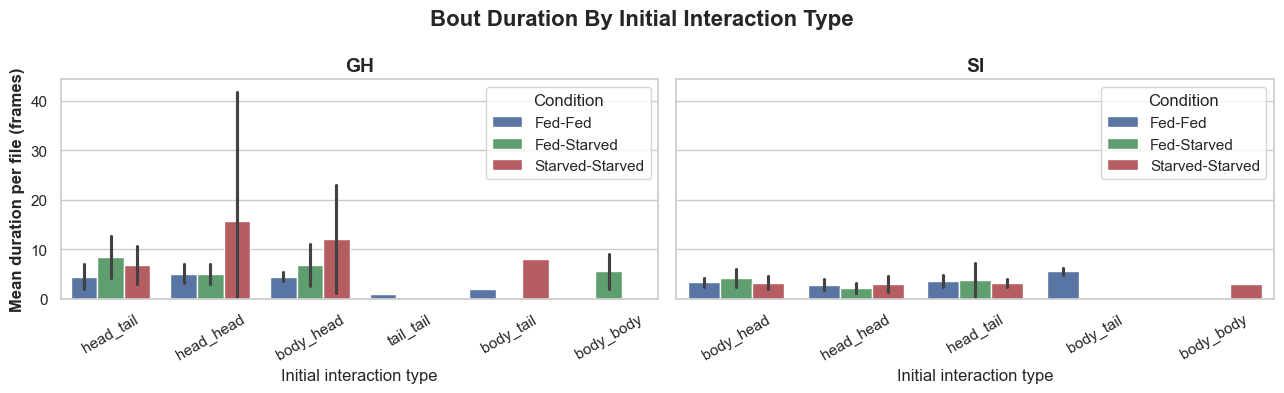

In [49]:
initial_type_duration = (
    bouts.groupby(['Condition', 'Housing', 'Feeding', 'file', 'initial_type'])['duration']
         .mean()
         .reset_index(name='mean_duration')
)

gh = initial_type_duration[initial_type_duration['Housing'] == 'GH'].copy()
si = initial_type_duration[initial_type_duration['Housing'] == 'SI'].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

sns.barplot(data=gh, x='initial_type', y='mean_duration', hue='Feeding', hue_order=feeding_order, palette=palette, ci='sd', ax=axes[0])
axes[0].set_title('GH', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Initial interaction type')
axes[0].set_ylabel('Mean duration per file (frames)', fontsize=12, fontweight='bold')
axes[0].set_ylim(bottom=0)
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(title='Condition')

sns.barplot(data=si, x='initial_type', y='mean_duration', hue='Feeding', hue_order=feeding_order, palette=palette, ci='sd', ax=axes[1])
axes[1].set_title('SI', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Initial interaction type')
axes[1].set_ylabel('')
axes[1].set_ylim(bottom=0)
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Condition')

fig.suptitle('Bout Duration By Initial Interaction Type', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Initial Interaction Type Durations Before Any Digging

/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_43198/1783492870.py:12: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=gh, x='initial_type', y='mean_duration', hue='Feeding', hue_order=feeding_order, palette=palette, ci='sd', ax=axes[0])
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_43198/1783492870.py:20: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=si, x='initial_type', y='mean_duration', hue='Feeding', hue_order=feeding_order, palette=palette, ci='sd', ax=axes[1])


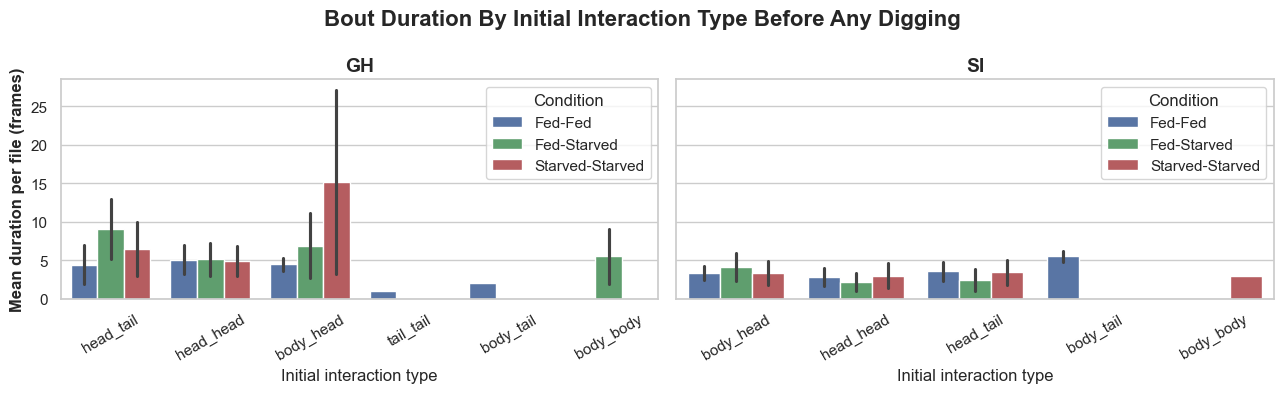

In [50]:
initial_type_duration_before = (
    bouts_before_digging.groupby(['Condition', 'Housing', 'Feeding', 'file', 'initial_type'])['duration']
                         .mean()
                         .reset_index(name='mean_duration')
)

gh = initial_type_duration_before[initial_type_duration_before['Housing'] == 'GH'].copy()
si = initial_type_duration_before[initial_type_duration_before['Housing'] == 'SI'].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

sns.barplot(data=gh, x='initial_type', y='mean_duration', hue='Feeding', hue_order=feeding_order, palette=palette, ci='sd', ax=axes[0])
axes[0].set_title('GH', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Initial interaction type')
axes[0].set_ylabel('Mean duration per file (frames)', fontsize=12, fontweight='bold')
axes[0].set_ylim(bottom=0)
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(title='Condition')

sns.barplot(data=si, x='initial_type', y='mean_duration', hue='Feeding', hue_order=feeding_order, palette=palette, ci='sd', ax=axes[1])
axes[1].set_title('SI', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Initial interaction type')
axes[1].set_ylabel('')
axes[1].set_ylim(bottom=0)
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Condition')

fig.suptitle('Bout Duration By Initial Interaction Type Before Any Digging', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. First Interaction Ever

/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_43198/149290535.py:30: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=gh, x='initial_type', y='number_of_files', hue='Feeding', hue_order=feeding_order, palette=palette, ci='sd', ax=axes[0])
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_43198/149290535.py:38: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=si, x='initial_type', y='number_of_files', hue='Feeding', hue_order=feeding_order, palette=palette, ci='sd', ax=axes[1])


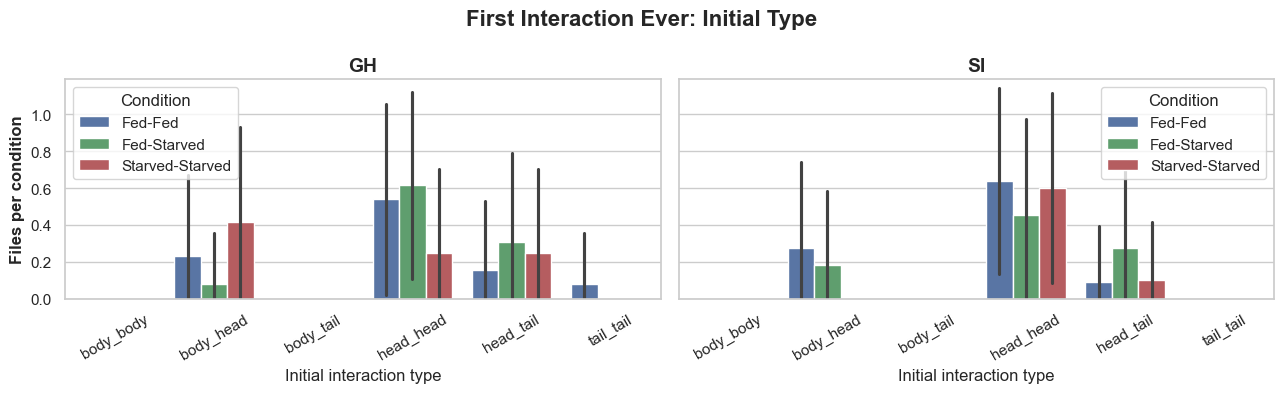

In [51]:
first_interaction = (
    bouts.sort_values(['Condition', 'file', 'start_frame'])
         .groupby(['Condition', 'Housing', 'Feeding', 'file'])
         .head(1)
         .copy()
)

first_type_counts = (
    first_interaction.groupby(['Condition', 'Housing', 'Feeding', 'file', 'initial_type'])
                     .size()
                     .reset_index(name='number_of_files')
)

filled = []
for condition in condition_order:
    files = all_files[all_files['Condition'] == condition][['Condition', 'Housing', 'Feeding', 'file']]
    temp_index = pd.MultiIndex.from_product([files['file'].unique(), interaction_type_order], names=['file', 'initial_type'])
    temp = temp_index.to_frame(index=False).merge(files, on='file', how='left')
    temp = temp.merge(first_type_counts, on=['Condition', 'Housing', 'Feeding', 'file', 'initial_type'], how='left')
    temp['number_of_files'] = temp['number_of_files'].fillna(0)
    filled.append(temp)

first_type_counts = pd.concat(filled, ignore_index=True)

gh = first_type_counts[first_type_counts['Housing'] == 'GH'].copy()
si = first_type_counts[first_type_counts['Housing'] == 'SI'].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

sns.barplot(data=gh, x='initial_type', y='number_of_files', hue='Feeding', hue_order=feeding_order, palette=palette, ci='sd', ax=axes[0])
axes[0].set_title('GH', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Initial interaction type')
axes[0].set_ylabel('Files per condition', fontsize=12, fontweight='bold')
axes[0].set_ylim(bottom=0)
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(title='Condition')

sns.barplot(data=si, x='initial_type', y='number_of_files', hue='Feeding', hue_order=feeding_order, palette=palette, ci='sd', ax=axes[1])
axes[1].set_title('SI', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Initial interaction type')
axes[1].set_ylabel('')
axes[1].set_ylim(bottom=0)
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Condition')

fig.suptitle('First Interaction Ever: Initial Type', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_43198/2114053271.py:12: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=gh, x='initial_type', y='mean_duration', hue='Feeding', hue_order=feeding_order, palette=palette, ci='sd', ax=axes[0])
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_43198/2114053271.py:20: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=si, x='initial_type', y='mean_duration', hue='Feeding', hue_order=feeding_order, palette=palette, ci='sd', ax=axes[1])


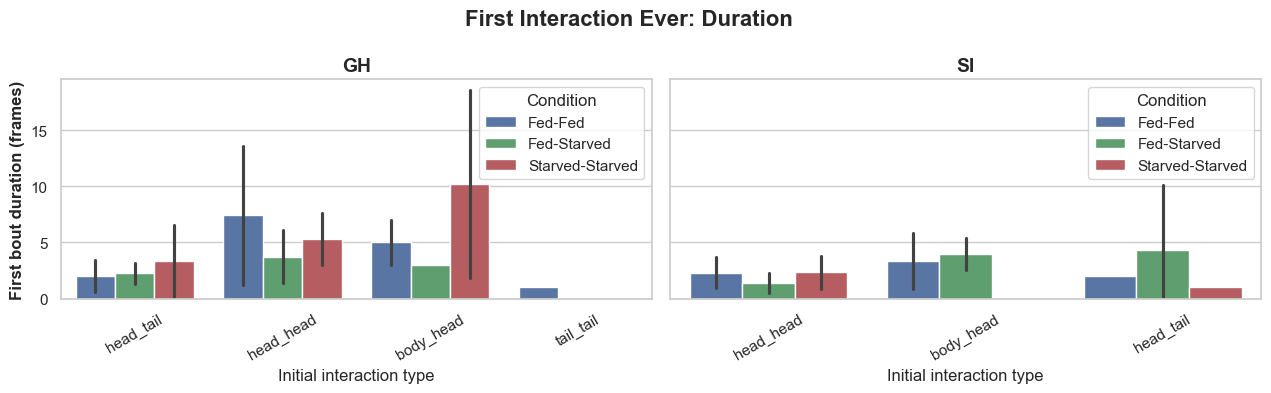

,Condition,file,start_frame,duration,initial_type,start_dug_context
0,GH Fed-Fed,2026-03-09_12-32-18_td9.tracks.feather,1109,1,head_tail,neither_dug
1,GH Fed-Fed,2026-03-09_12-35-46_td11.tracks.feather,375,2,head_head,neither_dug
8,GH Fed-Fed,2026-03-09_16-32-50_td1.tracks.feather,998,6,head_head,neither_dug
15,GH Fed-Fed,2026-03-09_16-34-18_td2.tracks.feather,78,7,body_head,neither_dug
36,GH Fed-Fed,2026-03-09_16-35-41_td3.tracks.feather,49,5,body_head,neither_dug


In [52]:
first_duration = (
    first_interaction.groupby(['Condition', 'Housing', 'Feeding', 'file', 'initial_type'])['duration']
                     .mean()
                     .reset_index(name='mean_duration')
)

gh = first_duration[first_duration['Housing'] == 'GH'].copy()
si = first_duration[first_duration['Housing'] == 'SI'].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

sns.barplot(data=gh, x='initial_type', y='mean_duration', hue='Feeding', hue_order=feeding_order, palette=palette, ci='sd', ax=axes[0])
axes[0].set_title('GH', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Initial interaction type')
axes[0].set_ylabel('First bout duration (frames)', fontsize=12, fontweight='bold')
axes[0].set_ylim(bottom=0)
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(title='Condition')

sns.barplot(data=si, x='initial_type', y='mean_duration', hue='Feeding', hue_order=feeding_order, palette=palette, ci='sd', ax=axes[1])
axes[1].set_title('SI', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Initial interaction type')
axes[1].set_ylabel('')
axes[1].set_ylim(bottom=0)
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Condition')

fig.suptitle('First Interaction Ever: Duration', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

display(first_interaction[['Condition', 'file', 'start_frame', 'duration', 'initial_type', 'start_dug_context']].head())